# EDA for Team Win/Loss Record

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
import os


In [2]:
# Establishing file paths for loading and saving data
CLEANED_PATH = "../../data/teams_cleaned"
PROCESSED_PATH = "../../data/processed"
os.makedirs(PROCESSED_PATH, exist_ok=True)

The first phase of EDA will be to determine which categories matter most for the DPOY award

In [3]:
# Importing the merged data set from notebook 01
teams_df = pd.read_csv(f"{CLEANED_PATH}/team_all_years.csv")

In [4]:
# Previewing the data to ensure this is the correct DataFrame
teams_df.head(5)

,Team,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,...,Pace,FTr,3PAr,TS%,eFG%,TOV%,ORB%,FT/FGA,DRB%,Season
0,Phoenix Suns,40.7,82.8,0.492,8.9,21.6,0.412,31.8,61.2,0.520,...,95.3,0.312,0.261,0.585,0.546,13.6,27.6,0.240,70.8,2010
1,Golden State Warriors,40.6,86.5,0.469,7.7,20.6,0.375,32.9,65.9,0.499,...,100.4,0.294,0.238,0.557,0.514,13.1,20.9,0.230,68.5,2010
2,Denver Nuggets,38.1,81.4,0.468,6.6,18.5,0.359,31.5,62.9,0.500,...,94.8,0.376,0.227,0.561,0.509,12.7,26.1,0.290,72.4,2010
3,Utah Jazz,39.4,80.2,0.491,5.4,14.7,0.364,34.0,65.5,0.519,...,93.8,0.340,0.184,0.565,0.524,14.2,26.8,0.252,75.6,2010
4,Toronto Raptors,39.0,80.9,0.482,6.3,17.0,0.371,32.7,63.8,0.512,...,93.1,0.319,0.211,0.564,0.521,12.7,24.7,0.244,72.9,2010


In [6]:
numeric_cols = teams_df.select_dtypes(include=["number"]).columns
team_corr_matrix = teams_df[numeric_cols].corr()

In [7]:
team_corr = team_corr_matrix["W"].drop("W").sort_values(ascending=False)
print(team_corr)

NRtg      0.943866
MOV       0.943046
SRS       0.941179
FG%       0.597467
ORtg      0.568922
3P%       0.555005
TS%       0.541699
eFG%      0.505345
2P%       0.405254
DRB       0.330356
PTS       0.313405
FG        0.287456
AST       0.255873
BLK       0.241705
TRB       0.240713
DRB%      0.231359
FT/FGA    0.222634
FT        0.210417
FT%       0.195828
3P        0.187495
FTr       0.155805
STL       0.150219
FTA       0.137035
3PAr      0.128899
3PA       0.101363
2P        0.073800
ORB%      0.025119
Season    0.003814
Pace     -0.062901
FGA      -0.089192
ORB      -0.147629
PF       -0.186773
2PA      -0.200401
TOV%     -0.240320
TOV      -0.310078
SOS      -0.356556
DRtg     -0.459980
L        -0.909886
Name: W, dtype: float64


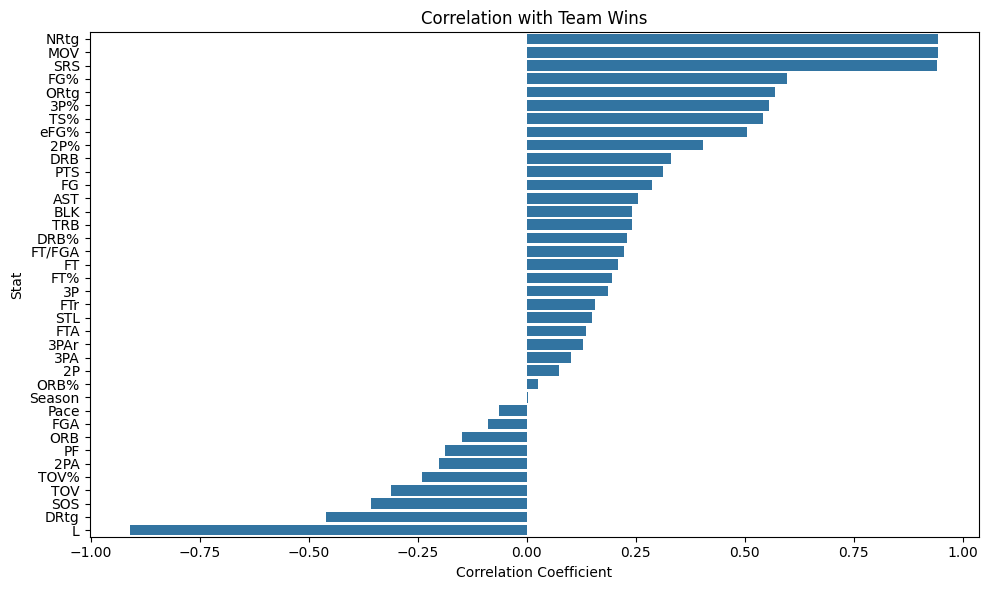

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(x=team_corr.values, y=team_corr.index)
plt.title("Correlation with Team Wins")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Stat")
plt.tight_layout()
plt.show()

Based on the results here, we're going to take everything with a correlation coefficient >.20

In [9]:
important_stats = team_corr[team_corr > 0.20].index

In [10]:
team_eda = teams_df[list(important_stats) + ["W"]]

In [11]:
print(team_eda.head())
print(f"{team_eda.shape[1]-1} stats selected with correlation > 0.20")

   NRtg   MOV   SRS    FG%   ORtg    3P%    TS%   eFG%    2P%   DRB    PTS  \
0   5.1  4.90  4.67  0.492  115.3  0.412  0.585  0.546  0.520  31.9  110.2   
1  -3.6 -3.60 -3.28  0.469  108.1  0.375  0.557  0.514  0.499  29.2  108.8   
2   4.3  4.09  4.15  0.468  111.8  0.359  0.561  0.509  0.500  30.5  106.5   
3   5.7  5.34  5.33  0.491  110.7  0.364  0.565  0.524  0.519  31.6  104.2   
4  -1.9 -1.78 -1.83  0.482  111.3  0.371  0.564  0.521  0.512  30.6  104.1   

     FG   AST  BLK   TRB  DRB%  FT/FGA    FT     W  
0  40.7  23.3  5.1  43.0  70.8   0.240  19.9  54.0  
1  40.6  22.4  4.1  38.4  68.5   0.230  19.9  26.0  
2  38.1  21.0  5.1  41.4  72.4   0.290  23.6  53.0  
3  39.4  26.7  4.9  42.2  75.6   0.252  20.2  53.0  
4  39.0  22.0  4.7  40.4  72.9   0.244  19.7  40.0  
18 stats selected with correlation > 0.20


Now that we know the correlation between individual stats and the PPG Leader, we're going to check for correlation between individual stats and reduce redundancies

In [12]:
# Select numeric feature columns excluding the target (PPG Leader)
features_only = team_eda.drop(columns=["W"])

In [13]:
# Compute the correlation matrix with absolute values
corr = features_only.corr().abs()

In [14]:
# Convert correlation to disatance (1 - correlation)
distance_matrix = 1 - corr

In [15]:
# Use hierarchical clustering (linkage) on the distance matrix
linkage_matrix = linkage(distance_matrix, method="ward")

C:\Users\bartl\AppData\Local\Temp\ipykernel_51064\187123466.py:2: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance_matrix, method="ward")


Plotting and using a dendrogram to determine correlation between columns. Features are joined closer to the left are more correlated

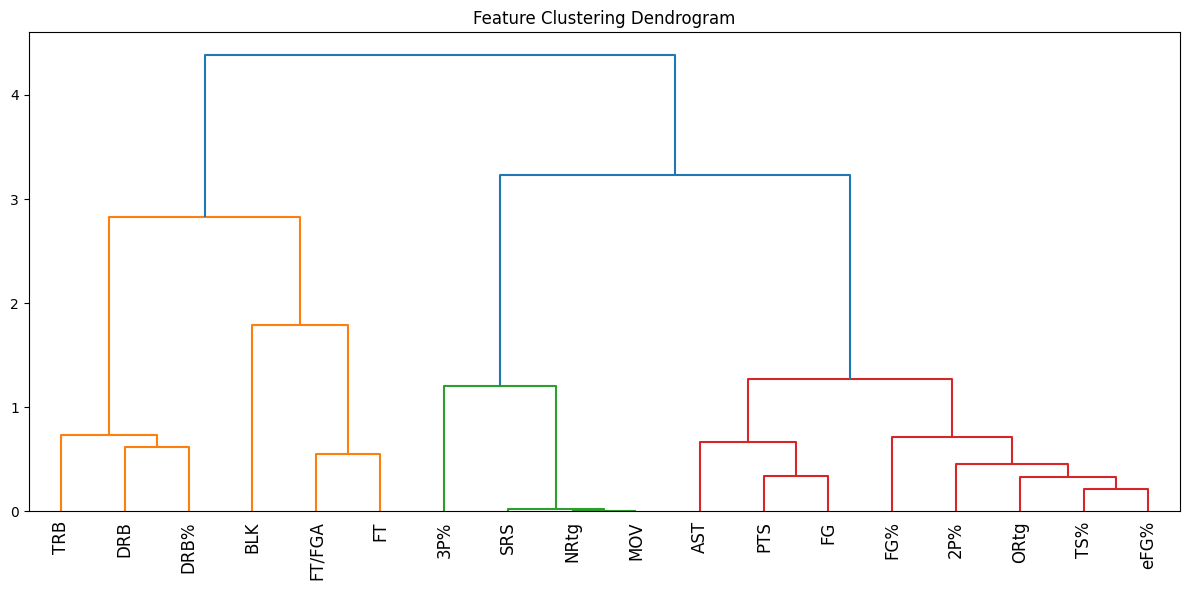

In [16]:
# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=corr.columns, leaf_rotation=90)
plt.title("Feature Clustering Dendrogram")
plt.tight_layout()
plt.show()

In [17]:
feature_corr = team_eda.drop(columns=["W"]).corr()

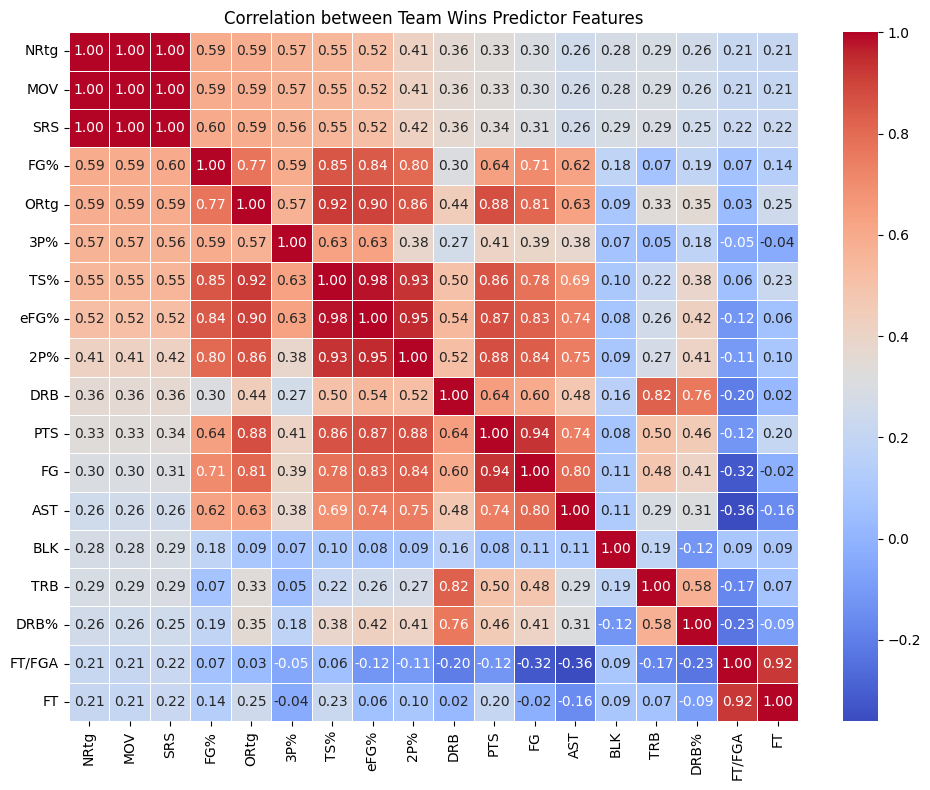

In [18]:
# Visualizing the data using a Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(feature_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation between Team Wins Predictor Features")
plt.tight_layout()
plt.show()

In [19]:
# Creating a correlation matrix of absolute values
corr_matrix = team_eda.drop(columns=["W"]).corr().abs()

In [20]:
# Selecting the upper triangle to avoid duplicate pairs
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [21]:
# Finding highly correlated feature pairs (pairs over >.85)
high_corr_features = [
    column for column in upper.columns if any(upper[column] > 0.85)
]
print(f"Features to consider droppong due to high correlation: \n{high_corr_features}")

Features to consider droppong due to high correlation: 
['MOV', 'SRS', 'TS%', 'eFG%', '2P%', 'PTS', 'FG', 'FT']


Based on domain knowledge, we're not going to drop the suggestion columns from the upper triangle. Instead we're going to use the results of the dendrogram and drop the columns to the far left. 

In [22]:
columns_to_drop = ["TRB", "DRB", "DRB%", "BLK", "FT/FGA", "FT"]
reduced_df = team_eda.drop(columns=columns_to_drop)

In [23]:
reduced_df.head(5)

,NRtg,MOV,SRS,FG%,ORtg,3P%,TS%,eFG%,2P%,PTS,FG,AST,W
0,5.1,4.90,4.67,0.492,115.3,0.412,0.585,0.546,0.520,110.2,40.7,23.3,54.0
1,-3.6,-3.60,-3.28,0.469,108.1,0.375,0.557,0.514,0.499,108.8,40.6,22.4,26.0
2,4.3,4.09,4.15,0.468,111.8,0.359,0.561,0.509,0.500,106.5,38.1,21.0,53.0
3,5.7,5.34,5.33,0.491,110.7,0.364,0.565,0.524,0.519,104.2,39.4,26.7,53.0
4,-1.9,-1.78,-1.83,0.482,111.3,0.371,0.564,0.521,0.512,104.1,39.0,22.0,40.0


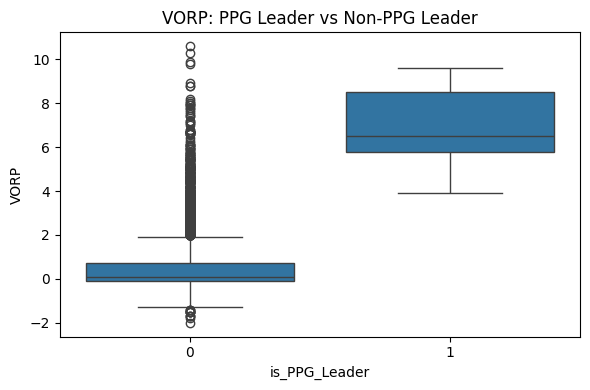

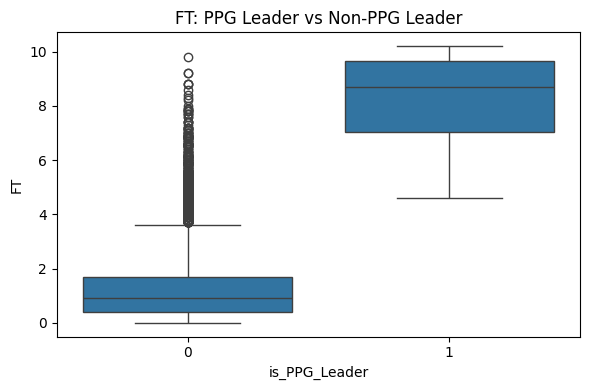

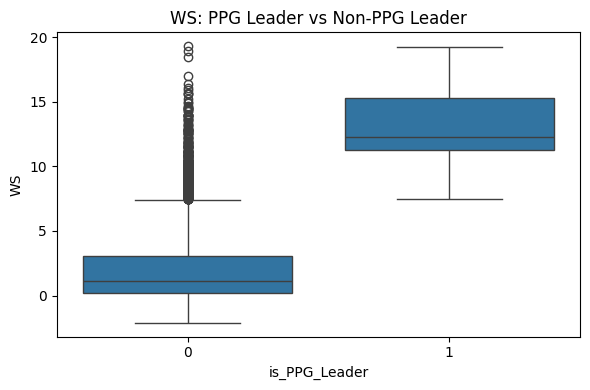

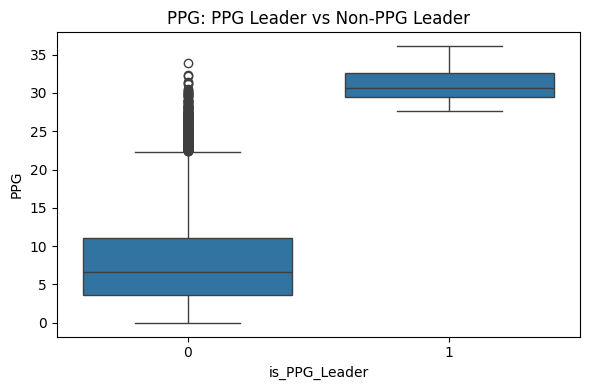

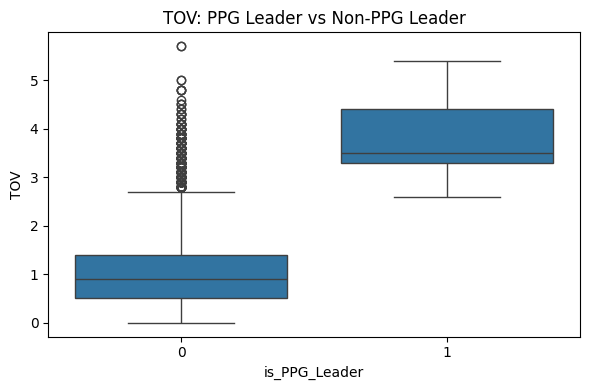

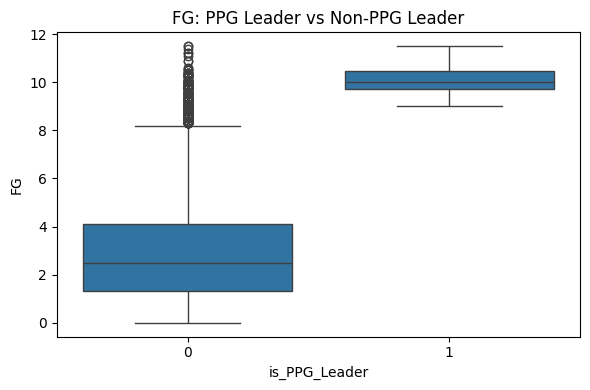

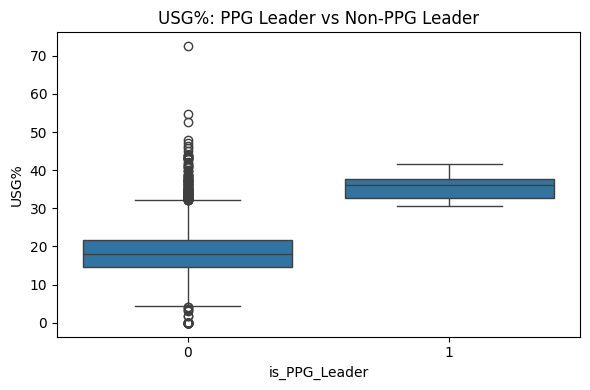

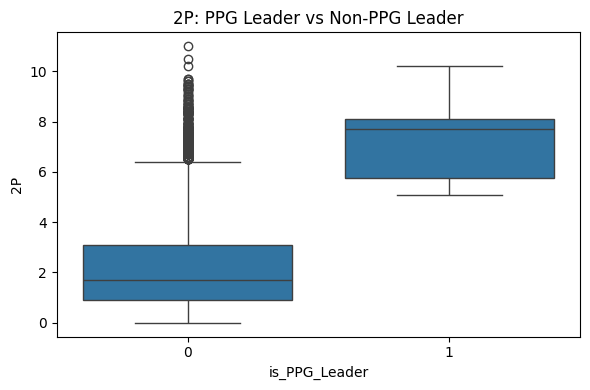

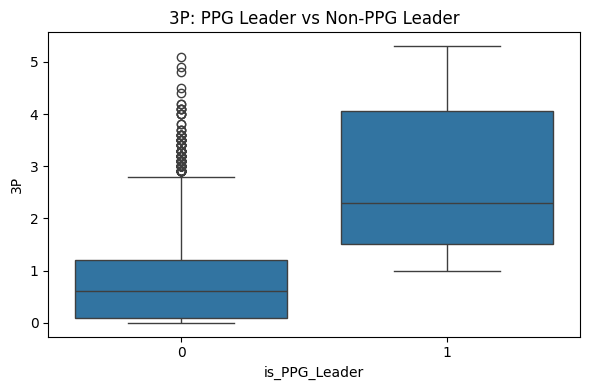

In [ ]:
# Visualizing Team Wins vs Non-PPG Leader for Key Features (0 = Non-PPG Leader, 1 = PPG Leader)
for col in reduced_df.columns:
    if col != "is_PPG_Leader":
        plt.figure(figsize=(6,4))
        sns.boxplot(x="is_PPG_Leader", y=col, data=reduced_df)
        plt.title(f"{col}: PPG Leader vs Non-PPG Leader")
        plt.tight_layout()
        plt.show()

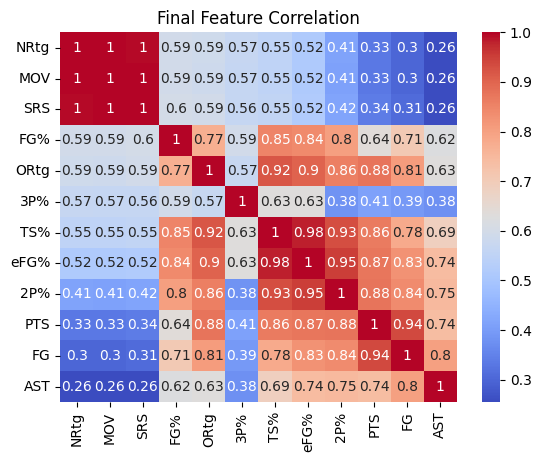

In [25]:
# One last check for redundancy
sns.heatmap(reduced_df.drop(columns="W").corr(), annot=True, cmap="coolwarm")
plt.title("Final Feature Correlation")
plt.show()

In [29]:
# Dropping 2P since it is so closely correlated with FTA
last_drop = ["2P", "FT", "WS"]
ppg_eda.drop(columns=last_drop)

,VORP,FTA,OWS,PPG,TOV,FG,FGA,USG%,2PA,3P,is_PPG_Leader
0,7.5,10.2,11.1,30.1,3.3,9.7,20.3,32.0,16.1,1.6,1
1,10.3,10.2,13.3,29.7,3.4,10.1,20.1,33.5,15.0,1.7,0
2,2.9,8.9,5.6,28.2,3.0,10.0,21.8,33.4,19.1,0.9,0
3,4.4,7.4,5.4,27.0,3.2,9.8,21.5,32.3,17.4,1.4,0
4,7.9,9.1,8.5,26.6,3.3,9.3,19.6,34.9,16.5,0.9,0
...,...,...,...,...,...,...,...,...,...,...,...
9711,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.8,0.5,0.0,0
9712,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
9713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
9714,0.0,0.0,0.0,0.0,0.0,0.0,0.5,21.6,0.5,0.0,0


In [30]:
reduced_df.to_csv(f"{PROCESSED_PATH}/ppg_eda_cleaned.csv")
print(f"ppg_eda_cleaned saved to {PROCESSED_PATH}")

ppg_eda_cleaned saved to ../../data/processed
